In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

import joblib

print(f"Libraries imported successfully")

#load saved data
X_train = joblib.load('data/X_train.pkl')
X_test = joblib.load('data/X_test.pkl')
y_train = joblib.load('data/y_train.pkl')
y_test = joblib.load('data/y_test.pkl')
class_weights = joblib.load('models/class_weights.pkl')

print(f"\nData loaded successfully!")
print(f"   Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"   Testing set: {X_test.shape[0]:,} samples")
print(f"   Class weights: {class_weights}")

C:\Users\User\AppData\Local\Temp\ipykernel_30864\3391719654.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Libraries imported successfully

Data loaded successfully!
   Training set: 71,236 samples, 2431 features
   Testing set: 30,530 samples
   Class weights: {0: 0.5628090123770864, 1: 4.480320507176191}


In [2]:
#create evaluation function

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """train and evaluate a model with proper metrics for imbalancesd data"""

    print(f" {model_name}")
    print("="*60)

    #train the model
    print('Training model.....')
    model.fit(X_train, y_train)

    #make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]  ### probability for positive class

    #calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    #print results
    print(f"\nPerformance Metrics:")
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"   F1-Score:  {f1:.4f}")
    print(f"   ROC-AUC:   {roc_auc:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    print(f"\nConfusion Matrix:")
    print(f"   True Negatives (correctly predicted NO):  {cm[0,0]:,}")
    print(f"   False Positives (wrongly predicted YES): {cm[0,1]:,}")
    print(f"   False Negatives (missed readmissions):   {cm[1,0]:,}")
    print(f"   True Positives (correctly predicted YES): {cm[1,1]:,}")

    # for imbalanced data--- recall is important
    print(f"\n CRITICAL METRICS for Hospital:")
    print(f"    Recall = {recall:.4f} - How many ACTUAL readmissions we caught")
    print(f"    False Negatives = {cm[1,0]:,} - Missed high-risk patients (DANGEROUS!)")

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm,
        'model': model
    }

print("Evaluation function created!")    

Evaluation function created!


In [3]:
# random forest -------------> good baseline, handles imbalance
#___________________________________________________________________

print("TRAINING RANDOM FOREST")
print("="*30)

#create random forest model with class weights
rf_model = RandomForestClassifier(
    n_estimators=100,   #no of trees
    max_depth=10,      #maximum depth of each tree
    min_samples_split = 50,    #mininmum samples to split a ndoe
    min_samples_leaf = 25,         #minimum samples in a leaf
    class_weight=class_weights,    #handle imbalance
    random_state=42,              #
    n_jobs=-1           #use all cpu cores
)

#evaluate
rf_results = evaluate_model(rf_model, X_train, X_test, y_train, y_test, "RANDOM FOREST")

#save modle
joblib.dump(rf_model, 'models/random_forest_model.pkl')
print("\nModel saved: /model/random_forest_model.pkl")

TRAINING RANDOM FOREST
 RANDOM FOREST
Training model.....

Performance Metrics:
   Accuracy:  0.6594 (65.94%)
   Precision: 0.1719 (17.19%)
   Recall:    0.5377 (53.77%)
   F1-Score:  0.2605
   ROC-AUC:   0.6528

Confusion Matrix:
   True Negatives (correctly predicted NO):  18,298
   False Positives (wrongly predicted YES): 8,825
   False Negatives (missed readmissions):   1,575
   True Positives (correctly predicted YES): 1,832

 CRITICAL METRICS for Hospital:
    Recall = 0.5377 - How many ACTUAL readmissions we caught
    False Negatives = 1,575 - Missed high-risk patients (DANGEROUS!)

Model saved: /model/random_forest_model.pkl


In [4]:
#train XGBoost---------------- state-of-the-art, best for imbalance

#!pip install xgboost
from xgboost import XGBClassifier

print("TRAINING XGBOOST")
print("="*20)

#clean column names for XGBoost -- remove invalid characters [,],<
def clean_feature_names(df):
    """Clean column names by removing invalid characters for XGBoost"""
    df = df.copy()
    df.columns = [str(col).replace('[', '_').replace(']', '_').replace('<', '_') 
                  for col in df.columns]
    return df

#clean the data
X_train_clean = clean_feature_names(X_train)
X_test_clean = clean_feature_names(X_test)

#calculate scale_pos_weight for XGBoost --similar to class weights
#scale_pos_weight = (negative_samples / positive_samples)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Scale_pos_weight: {scale_pos_weight:.2f}")

#create XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  #handle imbalance
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

#evaluate
xgb_results = evaluate_model(xgb_model, X_train_clean, X_test_clean, y_train, y_test, "XGBOOST")

#save the model
joblib.dump(xgb_model, 'models/xgboost_model.pkl')
print("\n Model saved: ../models/xgboost_model.pkl")

TRAINING XGBOOST
Scale_pos_weight: 7.96
 XGBOOST
Training model.....

Performance Metrics:
   Accuracy:  0.6641 (66.41%)
   Precision: 0.1806 (18.06%)
   Recall:    0.5682 (56.82%)
   F1-Score:  0.2741
   ROC-AUC:   0.6728

Confusion Matrix:
   True Negatives (correctly predicted NO):  18,338
   False Positives (wrongly predicted YES): 8,785
   False Negatives (missed readmissions):   1,471
   True Positives (correctly predicted YES): 1,936

 CRITICAL METRICS for Hospital:
    Recall = 0.5682 - How many ACTUAL readmissions we caught
    False Negatives = 1,471 - Missed high-risk patients (DANGEROUS!)

 Model saved: ../models/xgboost_model.pkl


In [5]:
#train---logistic regression
print("TRAINING LOGISTIC REGRESSION")
print("="*30)

#create logistic regression model with class weights
lr_model = LogisticRegression(
    class_weight=class_weights,
    random_state=42,
    max_iter=1000,
    C=1.0   #regularization strength
)

#evaluate
lr_results = evaluate_model(lr_model, X_train, X_test, y_train, y_test, "LOGISTIC REGRESSION")

# Save the model
joblib.dump(lr_model, 'models/logistic_regression_model.pkl')
print("\nModel saved: models/logistic_regression_model.pkl")

TRAINING LOGISTIC REGRESSION
 LOGISTIC REGRESSION
Training model.....

Performance Metrics:
   Accuracy:  0.6381 (63.81%)
   Precision: 0.1633 (16.33%)
   Recall:    0.5439 (54.39%)
   F1-Score:  0.2512
   ROC-AUC:   0.6379

Confusion Matrix:
   True Negatives (correctly predicted NO):  17,629
   False Positives (wrongly predicted YES): 9,494
   False Negatives (missed readmissions):   1,554
   True Positives (correctly predicted YES): 1,853

 CRITICAL METRICS for Hospital:
    Recall = 0.5439 - How many ACTUAL readmissions we caught
    False Negatives = 1,554 - Missed high-risk patients (DANGEROUS!)

Model saved: models/logistic_regression_model.pkl


____________________________________________________________
MODEL COMPARISON (Sorted by RECALL - Most Important)
____________________________________________________________
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
            XGBOOST  0.664068   0.180580 0.568242  0.274066 0.672828
LOGISTIC REGRESSION  0.638126   0.163303 0.543880  0.251186 0.637851
      RANDOM FOREST  0.659351   0.171906 0.537716  0.260523 0.652807


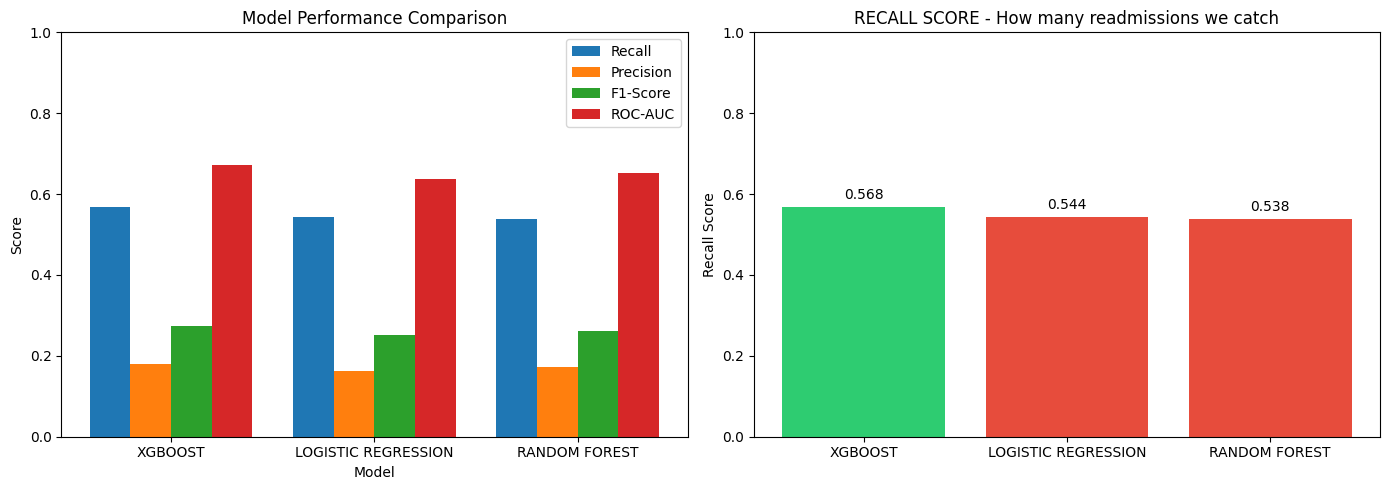


------------------------------------------------------------
FINAL RECOMMENDATION
____________________________________________________________
BEST MODEL: XGBOOST
   Recall: 0.5682 (56.82%)
   This model catches 56.8% of actual readmissions

Saving final model...
Final model saved: ../models/final_model.pkl


In [6]:
#compare model performances

results_list = [rf_results, xgb_results, lr_results]

#comparison dataframe
comparison_df = pd.DataFrame([
    {
        'Model':r['model_name'],
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1'],
        'ROC-AUC': r['roc_auc']
    }
    for r in results_list
])

#sort by recall
comparison_df = comparison_df.sort_values('Recall', ascending=False)

print("_"*60)
print("MODEL COMPARISON (Sorted by RECALL - Most Important)")
print("_"*60)
print(comparison_df.to_string(index=False))

#visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14,5))


#bar plot----metrics
metrics = ['Recall', 'Precision', 'F1-Score', 'ROC-AUC']
x = np.arange(len(comparison_df['Model']))
width = 0.2

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, comparison_df[metric], width, label=metric)

axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(comparison_df['Model'])
axes[0].legend()
axes[0].set_ylim(0, 1)

#bar plot----recall only
colors = ['#2ecc71' if i==0 else '#e74c3c' for i in range(len(comparison_df))]
axes[1].bar(comparison_df['Model'], comparison_df['Recall'], color=colors)
axes[1].set_ylabel('Recall Score')
axes[1].set_title('RECALL SCORE - How many readmissions we catch')
axes[1].set_ylim(0, 1)
for i, v in enumerate(comparison_df['Recall']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

#recommend
best_model_row = comparison_df.iloc[0]
print("\n" + "-"*60)
print("FINAL RECOMMENDATION")
print("_"*60)
print(f"BEST MODEL: {best_model_row['Model']}")
print(f"   Recall: {best_model_row['Recall']:.4f} ({best_model_row['Recall']*100:.2f}%)")
print(f"   This model catches {best_model_row['Recall']*100:.1f}% of actual readmissions")
print(f"\nSaving final model...")

#save best model
if best_model_row['Model'] == "RANDON FOREST":
    final_model = rf_model
elif best_model_row['Model'] == "XGBOOST":
    final_model = xgb_model
else:
    final_model = lr_model

joblib.dump(final_model, 'models/final_model.pkl')
print("Final model saved: ../models/final_model.pkl")

FEATURE IMPORTANCE ANALYSIS

TOP 20 MOST IMPORTANT FEATURES:
   10. number_inpatient                                   : 0.0311
   2. discharge_disposition_id                           : 0.0115
   623. diag_1_715                                         : 0.0094
   398. diag_1_428                                         : 0.0065
   12. total_visits                                       : 0.0064
   831. diag_1_V57                                         : 0.0061
   2423. glyburide-metformin_No                             : 0.0055
   1153. diag_2_493                                         : 0.0054
   404. diag_1_434                                         : 0.0052
   401. diag_1_431                                         : 0.0051
   1736. diag_3_287                                         : 0.0050
   97. medical_specialty_Psychiatry                       : 0.0050
   453. diag_1_493                                         : 0.0050
   519. diag_1_577                                       

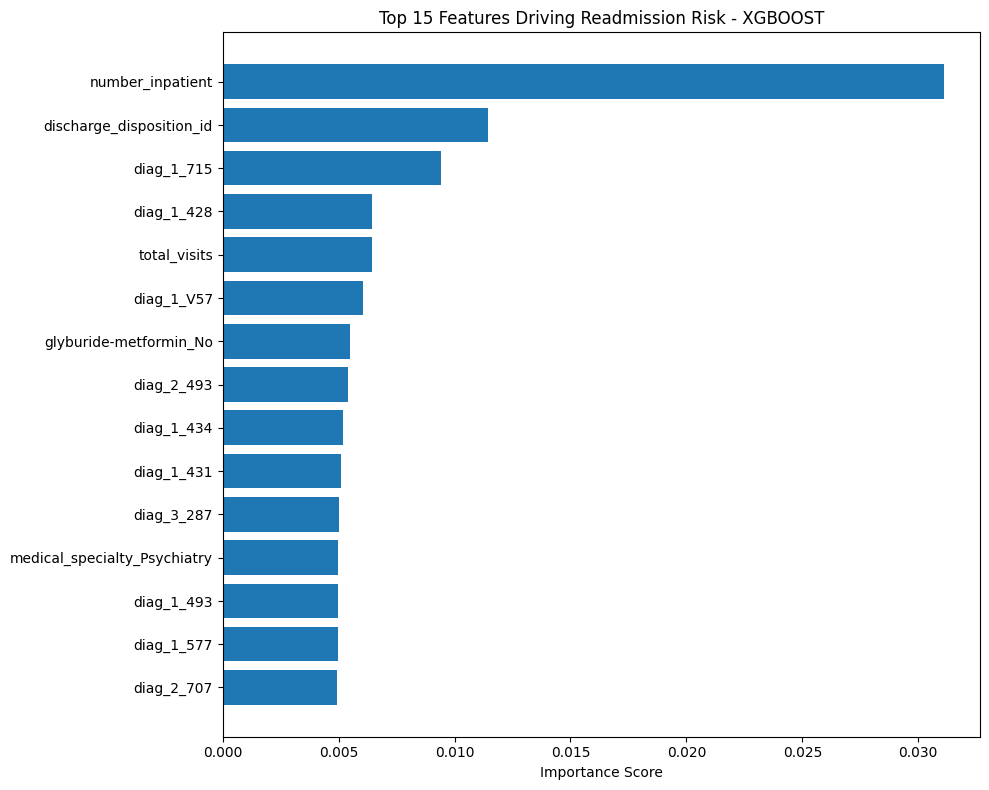

In [9]:
### feature importance ----- which factors matter most

print("FEATURE IMPORTANCE ANALYSIS")
print("="*30)

#get feature importance from best model
if best_model_row['Model'] == "RANDOM FOREST":
    importances = final_model.feature_importances_
elif best_model_row['Model'] == "XGBOOST":
    importances = final_model.feature_importances_
else:
    importances = np.abs(final_model.coef_[0])

#dataframe ---feature importance
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'feature':feature_names,
    'importance':importances
}).sort_values('importance', ascending=False)

#top 20 features
print("\nTOP 20 MOST IMPORTANT FEATURES:")
print("="*60)
for i, row in feature_importance_df.head(20).iterrows():
    print(f"   {i+1}. {row['feature'][:50]:50s} : {row['importance']:.4f}")

#visualize top 15
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance Score')
plt.title(f'Top 15 Features Driving Readmission Risk - {best_model_row["Model"]}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

In [12]:
## summary
print("MODEL TRAINING COMPLETE")
print("_"*30)

print("\nDATASET SUMMARY:")
print(f"   Total patients: 101,766")
print(f"   Readmission rate: 11.16%")
print(f"   Features used: {X_train.shape[1]}")

print("\nMODELS TRAINED:")
print(f"   1. Random Forest - Recall: {rf_results['recall']:.4f}")
print(f"   2. XGBoost - Recall: {xgb_results['recall']:.4f}")
print(f"   3. Logistic Regression - Recall: {lr_results['recall']:.4f}")

print(f"\nBEST MODEL: {best_model_row['Model']}")
print(f"   Catches {best_model_row['Recall']*100:.1f}% of all readmissions")
print(f"   Precision: {best_model_row['Precision']*100:.1f}%")
print(f"   ROC-AUC: {best_model_row['ROC-AUC']:.4f}")


MODEL TRAINING COMPLETE
______________________________

DATASET SUMMARY:
   Total patients: 101,766
   Readmission rate: 11.16%
   Features used: 2431

MODELS TRAINED:
   1. Random Forest - Recall: 0.5377
   2. XGBoost - Recall: 0.5682
   3. Logistic Regression - Recall: 0.5439

BEST MODEL: XGBOOST
   Catches 56.8% of all readmissions
   Precision: 18.1%
   ROC-AUC: 0.6728
